In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style for better visuals
sns.set(style="whitegrid")

In [ ]:
iris = sns.load_dataset('iris')
print("Dataset Shape:", iris.shape)
iris.head()


Dataset Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# List of columns with their data types
print("Feature Data Types:\n")
print(iris.dtypes)

# Separate features into numeric and nominal
numeric_features = iris.select_dtypes(include='number').columns.tolist()
nominal_features = iris.select_dtypes(include='object').columns.tolist()

print("\nNumeric Features:", numeric_features)
print("Nominal Features:", nominal_features)


Feature Data Types:

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Numeric Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Nominal Features: ['species']


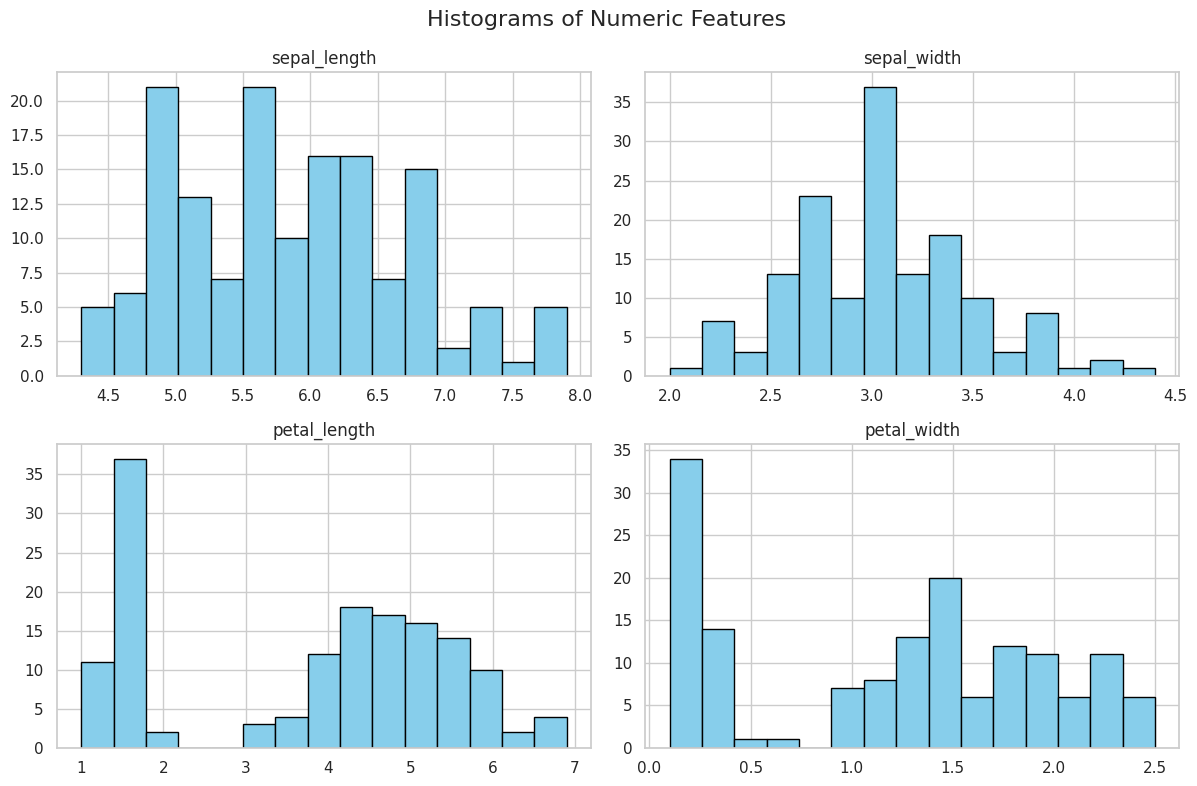

In [ ]:
# Histograms for all numeric features
iris[numeric_features].hist(bins=15, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

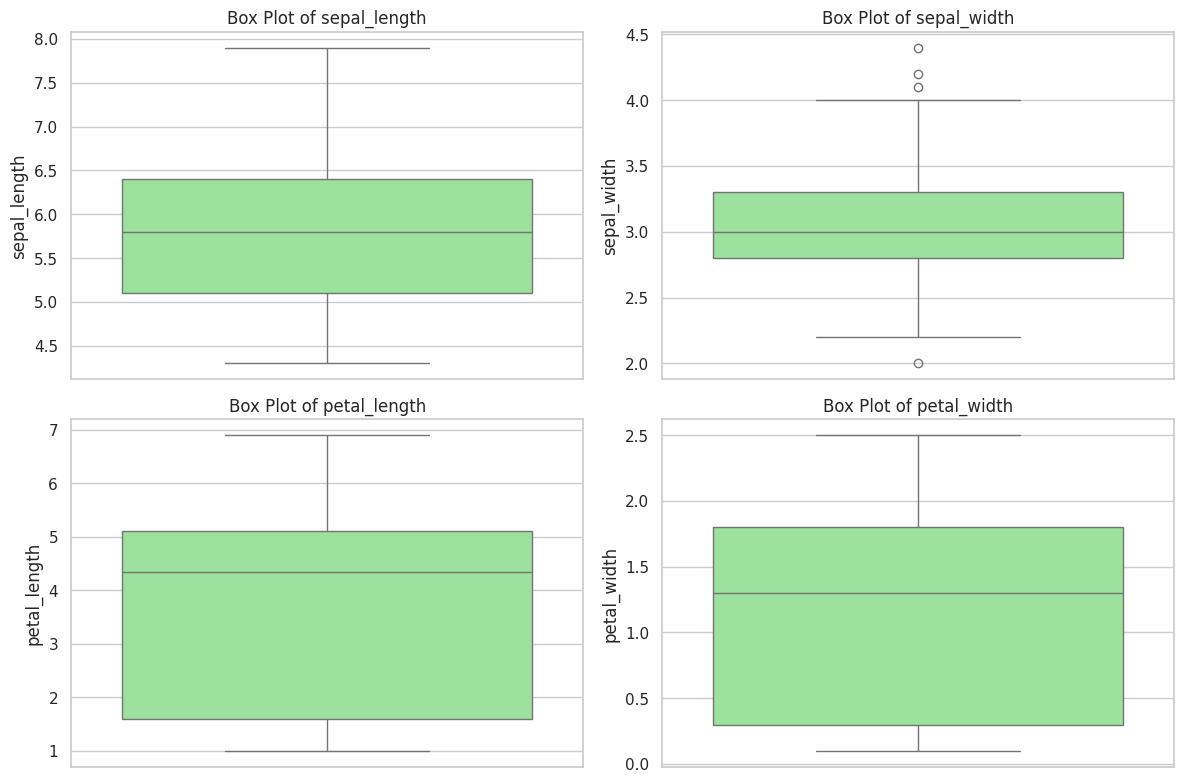

In [ ]:
# Boxplots for each numeric feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=iris, y=feature, color='lightgreen')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [ ]:
# Get summary statistics to help identify outliers
iris[numeric_features].describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Optional: Print outliers using IQR method
print("Outliers based on IQR method:\n")

for feature in numeric_features:
    Q1 = iris[feature].quantile(0.25)
    Q3 = iris[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = iris[(iris[feature] < lower_bound) | (iris[feature] > upper_bound)]
    print(f"{feature} → Outliers found: {outliers.shape[0]}")

Outliers based on IQR method:

sepal_length → Outliers found: 0
sepal_width → Outliers found: 4
petal_length → Outliers found: 0
petal_width → Outliers found: 0
